## El objetivo es visualizar la diferencia entre estabilidad y velocidad de convergencia. Para ello, vamos a ajustar un polinomio a un set de datos ruidoso. La función real es un polinomio de grado 3.  

## Generar Ambiente

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

SEED = 42
np.random.seed(SEED)

n_points = 1000
noise_std = 10


## Paso 1. Generacion de Datos
Genere 1000 puntos de datos basados en la función: 𝑦 = 2𝑥3 − 3𝑥2 + 5𝑥 + 3  

Agregue ruido aleatorio normal a y  para que los puntos no sean perfectos.  

Normalice los datos (muy importante para que el gradiente funcione bien)..  

x rango: -10.0 a 10.0
y_true ejemplo: [-2347.         -2333.71192111 -2320.47424689 -2307.28688104
 -2294.14972728]
y_noisy ejemplo: [-2353.75178275 -2335.15710782 -2328.3984461  -2310.36649634
 -2313.08587395]
x_norm rango: 0.0 a 1.0
y_norm rango: 0.0 a 1.0


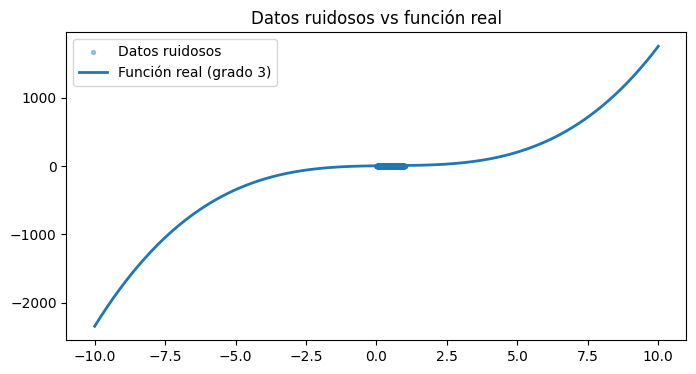

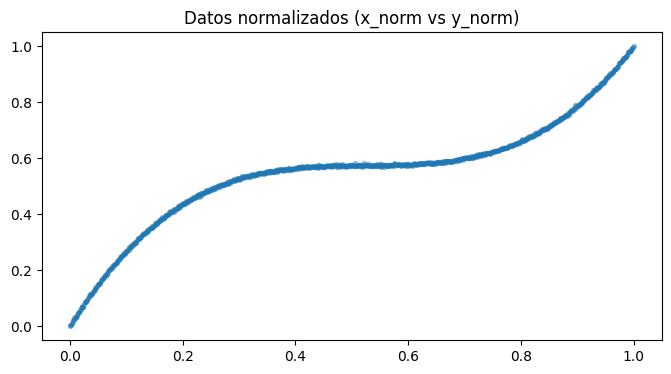

In [5]:
# generar 1000 puntos 
x = np.linspace(-10, 10, n_points)

# Función real (polinomio grado 3)
y_true = 2 * x**3 - 3 * x**2 + 5 * x + 3

# Ruido normal
noise = np.random.normal(loc=0, scale=noise_std, size=n_points)
y_noisy = y_true + noise

print("x rango:", x.min(), "a", x.max())
print("y_true ejemplo:", y_true[:5])
print("y_noisy ejemplo:", y_noisy[:5])

# Normalizar datos
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y_noisy - y_noisy.min()) / (y_noisy.max() - y_noisy.min())

print("x_norm rango:", x_norm.min(), "a", x_norm.max())
print("y_norm rango:", y_norm.min(), "a", y_norm.max())

# Visual: datos ruidosos vs función real
plt.figure(figsize=(8,4))
plt.scatter(x_norm, y_norm, s=8, alpha=0.4, label="Datos ruidosos")
plt.plot(x, y_true, linewidth=2, label="Función real (grado 3)")
plt.legend()
plt.title("Datos ruidosos vs función real")
plt.show()
plt.figure(figsize=(8,4))
plt.scatter(x_norm, y_norm, s=8, alpha=0.4)
plt.title("Datos normalizados (x_norm vs y_norm)")
plt.show()



## Implementación de Algoritmos:  
Implemente una función para Batch Gradient Descent (usa todos los datos para 1 paso).  

Implemente una función para Stochastic Gradient Descent (SGD) (usa 1 dato aleatorio para 1 paso).  

Implemente una función para Mini-batch Gradient Descent (usa un lote de n=32 datos para 1 paso).   

Nota: Debe calcular las derivadas del polinomio manualmente (o usar np.polyder como ayuda auxiliar, pero la lógica de actualización de pesos 𝑤 = 𝑤 − 𝜂 ⋅ ∇ debe ser suya).  

### Batch Gradient Descent

un método para ajustar los pesos  𝑤 del modelo, usando TODOS los datos en cada actualización.

X shape: (1000, 4)
y shape: (1000,)
Loss final: 0.005816831406836707
w final: [ 0.23811451  0.65877632 -0.03729043 -0.02103721]


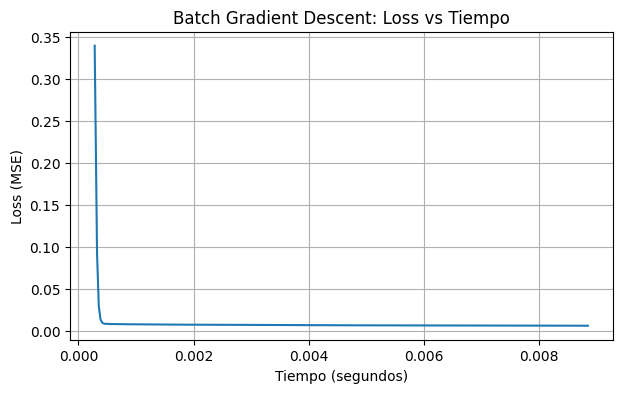

In [8]:
import time  # lo necesitas para medir tiempo

X = np.column_stack([
    np.ones_like(x_norm),
    x_norm,
    x_norm**2,
    x_norm**3
])

y = y_norm

print("X shape:", X.shape)  # debe ser (1000, 4)
print("y shape:", y.shape)  # debe ser (1000,)

def batch_gradient_descent(X, y, lr=0.5, epochs=200):
    # Inicializar pesos
    w = np.zeros(X.shape[1])
    losses = []
    times = []
    start = time.perf_counter()

    for _ in range(epochs):
        # Predicciones
        y_hat = X @ w
        #calcular pérdida (MSE) 
        loss = np.mean((y_hat - y)**2)
        # calcular gradiente
        n = X.shape[0]
        grad = (2/n) * (X.T @ (y_hat - y))
        # actualizar pesos
        w = w - lr * grad

        times.append(time.perf_counter() - start)
        losses.append(loss)

    return w, np.array(times), np.array(losses)

w_batch, t_batch, loss_batch = batch_gradient_descent(X, y, lr=0.5, epochs=300)
print("Loss final:", loss_batch[-1])
print("w final:", w_batch)

plt.figure(figsize=(7,4))
plt.plot(t_batch, loss_batch)
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Loss (MSE)")
plt.title("Batch Gradient Descent: Loss vs Tiempo")
plt.grid(True)
plt.show()


## Funcion para Stochastic Gradient Descent (SGD) (usa 1 dato aleatorio para 1 paso).

Loss final SGD: 0.057918296911759995
w final SGD: [ 0.05603895  0.55033482  0.0182339  -0.05619877]


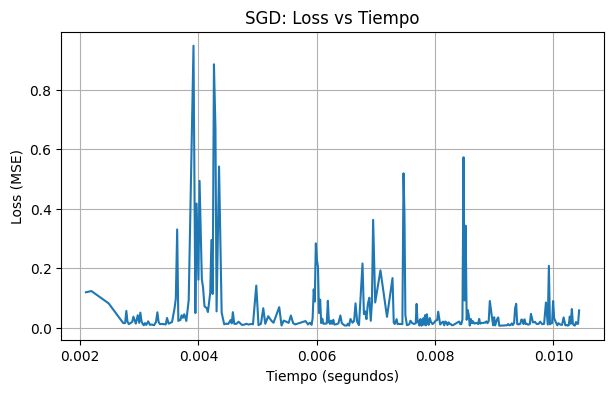

In [9]:
def stochastic_gradient_descent(X, y, lr=0.5, epochs=200, seed=42):
    """
    SGD: en cada paso usa 1 dato aleatorio (1 fila) para calcular el gradiente y actualizar w.
    Guarda (tiempo, loss) por epoch para graficar Loss vs Tiempo.
    """
    rng = np.random.default_rng(seed)

    w = np.zeros(X.shape[1])
    losses = []
    times = []
    start = time.perf_counter()

    n = X.shape[0]

    for _ in range(epochs):
        # 1) elegir un índice aleatorio
        i = rng.integers(0, n)

        # 2) tomar un solo punto (fila)
        Xi = X[i:i+1, :]     # shape (1,4)
        yi = y[i:i+1]        # shape (1,)

        # 3) predicción con ese punto
        y_hat_i = Xi @ w     # shape (1,)

        # 4) gradiente usando SOLO ese punto (n=1)
        grad = 2 * (Xi.T @ (y_hat_i - yi))  # (2/1) * Xi^T(...)

        # 5) update
        w = w - lr * grad

        # 6) medir loss global (en TODO el dataset) para monitoreo
        y_hat_all = X @ w
        loss = np.mean((y_hat_all - y)**2)

        times.append(time.perf_counter() - start)
        losses.append(loss)

    return w, np.array(times), np.array(losses)
w_sgd, t_sgd, loss_sgd = stochastic_gradient_descent(X, y, lr=0.5, epochs=300, seed=42)
print("Loss final SGD:", loss_sgd[-1])
print("w final SGD:", w_sgd)

#visuaizacion 
plt.figure(figsize=(7,4))
plt.plot(t_sgd, loss_sgd)
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Loss (MSE)")
plt.title("SGD: Loss vs Tiempo")
plt.grid(True)
plt.show()

